# Phase 9 — Rock Physics Modelling: Vs from Contact Cement

**Field**: Dvalin, Norwegian Sea

Builds a **VS_RPM** log using the Dvorkin-Nur contact cement model calibrated per formation.
Inputs: VP_OK, PHIT, RHOB_OK, VWCL, DIFF_PRESS from previous pipeline phases.

- **Step 9.1** — Load data
- **Step 9.2** — VRH mineral mixing (quartz + clay using VWCL)
- **Step 9.3** — Per-formation calibration of critical porosity φ_c
- **Step 9.4** — Apply model → VS_RPM log
- **Step 9.5** — Log display: VS_RPM vs VS_OK vs VS_Castagna
- **Step 9.6** — Vp–Vs crossplot with cement trend lines
- **Step 9.7** — Vp–φ crossplot with cement trend lines
- **Step 9.8** — Save output


In [1]:
import sys
sys.path.insert(0, '/Users/abd/Developer/qsi')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory
from pathlib import Path
from scipy.optimize import minimize_scalar
import lasio, importlib

import well_config; importlib.reload(well_config)
from well_config import get_cfg, set_plot_style, load_tops, form_colours, ACTIVE_WELL

from qsi.models.cement       import contact_cement
from qsi.models.cemented_sand import cemented_sand
from qsi.models.soft_sediments import soft_sediments
from qsi.moduli.bounds       import voigt_reuss_hill
from qsi.moduli.gassmann     import gassmann_sat
from qsi.fluids.batzle_wang  import brine_properties

# ── Well selection ────────────────────────────────────────────────────────────
WELL_NAME = ACTIVE_WELL
cfg       = get_cfg(WELL_NAME)
set_plot_style()

# ── Paths ─────────────────────────────────────────────────────────────────────
WELL_FILE   = Path('..') / cfg['las_file']
TOPS_FILE   = Path('..') / cfg['tops_file']
ELASTIC_IN  = Path(f'../wells/{WELL_NAME}_elastic.parquet')
RHOB_IN     = Path(f'../wells/{WELL_NAME}_rhob_ok.parquet')
COMPUTED_IN = Path(f'../wells/{WELL_NAME}_computed.parquet')
FAUST_IN    = Path(f'../wells/{WELL_NAME}_faust.parquet')
OUT_FILE    = Path(f'../wells/{WELL_NAME}_rockphysics.parquet')

# ── Mineral end-members (Pa, kg/m³) ──────────────────────────────────────────
K_QUARTZ  = 36.6e9;  G_QUARTZ  = 45.0e9;  RHO_QUARTZ  = 2650.0
K_CLAY    = 25.0e9;  G_CLAY    = 9.0e9;   RHO_CLAY    = 2580.0
K_CEMENT  = 36.6e9;  G_CEMENT  = 45.0e9   # quartz cement

# ── Contact cement model defaults ─────────────────────────────────────────────
PHI_C_GLOBAL = 0.40   # calibrated per formation in Step 9.3
CN           = 8.0    # coordination number (explore later)
SCHEME       = 2      # cement uniformly on grain surface

print('qsi imports OK')
print(f'Well: {WELL_NAME}')


qsi imports OK
Well: 65077-15S


## Step 9.1 — Load Data


In [2]:
# ── Load LAS (for PHIT, VWCL not yet in any parquet) ────────────────────────
las = lasio.read(WELL_FILE)
df  = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.rename(columns=cfg.get('curve_map', {}), inplace=True)
df.index.name = 'DEPTH_MD'

# ── Join all pipeline parquets ────────────────────────────────────────────────
for pq_path in [ELASTIC_IN, RHOB_IN, COMPUTED_IN, FAUST_IN]:
    tmp = pd.read_parquet(pq_path)
    df  = df.join(tmp[[c for c in tmp.columns if c not in df.columns]], how='left')

LOG_TOP  = cfg['log_top']  if cfg['log_top']  is not None else df.index[0]
LOG_BASE = cfg['log_base'] if cfg['log_base'] is not None else df.index[-1]
sub = df.loc[LOG_TOP:LOG_BASE].copy()

# ── Formation assignment ──────────────────────────────────────────────────────
f1a = load_tops(TOPS_FILE, cfg['tops_well_id'])
TOPS_MD       = dict(zip(f1a['PICKS'], f1a['DEPTH'])) if not f1a.empty else {}
FORM_COLORS   = form_colours(TOPS_MD.keys())
RESERVOIR_TOP = f1a.iloc[-1]['PICKS'] if not f1a.empty else None
top_list      = sorted(TOPS_MD.items(), key=lambda x: x[1])
sub['FORMATION'] = 'Other'
for _name, _md_top in top_list:
    sub.loc[sub.index >= _md_top, 'FORMATION'] = _name

# ── Confirm key columns ───────────────────────────────────────────────────────
print(f'Interval: {LOG_TOP}–{LOG_BASE} m MD  ({len(sub):,} samples)')
print()
for col in ['VP_OK','VS','VS_OK','RHOB_OK','PHIT','VWCL',
            'DIFF_PRESS','ELASTIC_EDIT','VP_SOURCE']:
    n = int(sub[col].notna().sum()) if col in sub.columns else -1
    tag = f'{n:,} valid' if n >= 0 else 'MISSING'
    print(f'  {col:<18}: {tag}')


Interval: 0.0–4589.9832 m MD  (30,119 samples)

  VP_OK             : 26,548 valid
  VS                : 15,378 valid
  VS_OK             : 26,613 valid
  RHOB_OK           : 26,566 valid
  PHIT              : 15,320 valid
  VWCL              : 15,320 valid
  DIFF_PRESS        : 30,119 valid
  ELASTIC_EDIT      : 30,112 valid
  VP_SOURCE         : 30,112 valid


## Step 9.2 — VRH Mineral Mixing

Hill average of quartz and clay using VWCL. `voigt_reuss_hill` from qsi is scalar-only,
so VRH is computed manually element-wise.


VRH mineral mixing complete
  K_min range: 26.46–36.60 GPa
  G_min range: 12.24–45.00 GPa
  Valid samples: 15,320


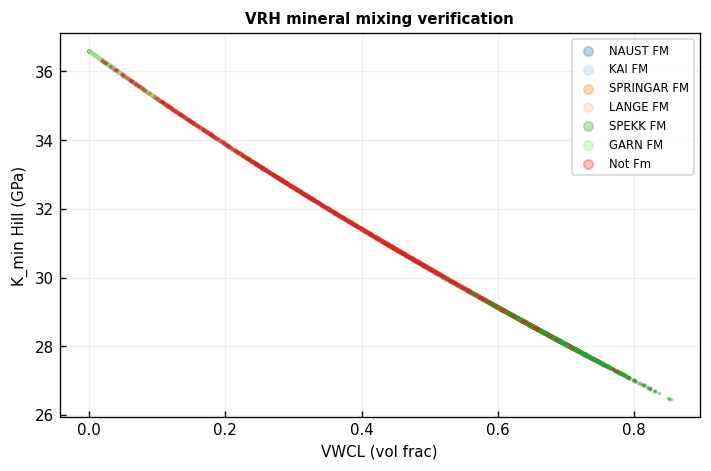

In [3]:
# ── VRH mineral mixing (element-wise, quartz + clay) ─────────────────────────
vwcl = np.clip(sub['VWCL'].values.astype(float), 1e-6, 1.0 - 1e-6)
vwcl = np.where(np.isnan(sub['VWCL'].values), np.nan, vwcl)
vqtz = 1.0 - np.where(np.isnan(vwcl), np.nan, vwcl)

# Voigt (upper)
k_v = vwcl * K_CLAY + vqtz * K_QUARTZ
g_v = vwcl * G_CLAY + vqtz * G_QUARTZ
# Reuss (lower)
k_r = 1.0 / (vwcl / K_CLAY + vqtz / K_QUARTZ)
g_r = 1.0 / (vwcl / G_CLAY + vqtz / G_QUARTZ)
# Hill average
sub['K_MIN'] = 0.5 * (k_v + k_r)
sub['G_MIN'] = 0.5 * (g_v + g_r)
sub['RHO_MIN'] = vwcl * RHO_CLAY + vqtz * RHO_QUARTZ

print('VRH mineral mixing complete')
print(f"  K_min range: {sub['K_MIN'].min()/1e9:.2f}–{sub['K_MIN'].max()/1e9:.2f} GPa")
print(f"  G_min range: {sub['G_MIN'].min()/1e9:.2f}–{sub['G_MIN'].max()/1e9:.2f} GPa")
print(f"  Valid samples: {sub['K_MIN'].notna().sum():,}")

# ── Quick verification: K_min vs VWCL scatter ─────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
form_order = [n for n,_ in top_list]
for fname in form_order:
    fd = sub[sub['FORMATION'] == fname]
    ax.scatter(fd['VWCL'], fd['K_MIN']/1e9, s=2, alpha=0.3,
               color=FORM_COLORS.get(fname,'#888'), label=fname, rasterized=True)
ax.set_xlabel('VWCL (vol frac)', fontsize=9)
ax.set_ylabel('K_min Hill (GPa)', fontsize=9)
ax.set_title('VRH mineral mixing verification', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, markerscale=4)
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()


## Step 9.3 — Per-Formation Calibration of φ_c

In `contact_cement`, cement fraction = φ_c − φ is computed internally — φ_c is the only
free calibration parameter. Minimise RMS(VS_pred − VS_meas) per formation using
`scipy.optimize.minimize_scalar`.

**Calibration domain**: samples with measured DTS (`VS.notna()`), measured Vp
(`VP_SOURCE==0`), no elastic edits (`ELASTIC_EDIT==0`), and valid PHIT/RHOB_OK/DIFF_PRESS.

**contact_cement note**: `g_frame[-1]` is always zeroed internally. Fix: append a dummy
endpoint so the zeroing only affects the dummy, then strip it.


In [4]:
# ── Brine properties (median T/P for calibration) ────────────────────────────
med_T = float(sub['TEMP'].median())
med_P = float(sub['DIFF_PRESS'].median())
SAL   = cfg.get('salinity_ppm', 35000)
_vp_br, _rho_br, _k_br = brine_properties(sal=SAL, P=med_P, T=med_T)
K_BRINE_MED  = float(_k_br)  * 1e9   # GPa → Pa
RHO_BRINE_MED = float(_rho_br) * 1e3  # g/cc → kg/m³
print(f'Brine  T={med_T:.1f}°C  P={med_P:.1f} MPa  sal={SAL} ppm')
print(f'       K={_k_br:.3f} GPa  rho={_rho_br:.3f} g/cc  Vp={_vp_br*1e3:.0f} m/s')

# ── Helper: VS from contact cement (vectorised, array k/g_grain) ──────────────
def cement_vs(phi_arr, k_min_arr, g_min_arr, rho_sat_arr, phi_c_val):
    """Return VS_pred (m/s) for each sample; NaN where phi >= phi_c."""
    valid = (phi_arr < phi_c_val) & (phi_arr > 0) & np.isfinite(phi_arr)
    vs_out = np.full(len(phi_arr), np.nan)
    if valid.sum() == 0:
        return vs_out
    pv = phi_arr[valid]
    kv = k_min_arr[valid]
    gv = g_min_arr[valid]
    rv = rho_sat_arr[valid] * 1000.0   # g/cc → kg/m³
    # Append dummy endpoint so contact_cement's [-1]=0 only hits the dummy
    phi_in = np.append(pv, phi_c_val * 0.999)
    k_in   = np.append(kv, kv[-1])
    g_in   = np.append(gv, gv[-1])
    _, g_frame = contact_cement(phi_in, phi_c_val, CN, g_in, k_in,
                                 G_CEMENT, K_CEMENT, K_BRINE_MED, SCHEME)
    gf = g_frame[:-1]   # strip dummy
    vs_out[valid] = np.sqrt(np.where(gf > 0, gf / rv, np.nan))
    return vs_out

# ── Per-formation calibration ─────────────────────────────────────────────────
phi_c_dict   = {}
calib_rows   = []

print()
print(f"{'Formation':<20} {'n_cal':>7} {'phi_c':>7} {'RMS (m/s)':>10} {'RMS%':>7}")
print('─' * 60)

for i, (fname, md_top) in enumerate(top_list):
    md_base = top_list[i+1][1] if i+1 < len(top_list) else LOG_BASE
    fm = sub.loc[md_top:md_base]

    cmask = (
        fm['VS'].notna() &
        (fm.get('VP_SOURCE',   pd.Series(0, index=fm.index)) == 0) &
        (fm.get('ELASTIC_EDIT', pd.Series(0, index=fm.index)) == 0) &
        fm['PHIT'].notna() & fm['RHOB_OK'].notna() &
        fm['DIFF_PRESS'].notna() & fm['K_MIN'].notna()
    )
    n_cal = int(cmask.sum())

    if n_cal < 30:
        phi_c_dict[fname] = PHI_C_GLOBAL
        print(f"{fname:<20} {n_cal:>7,}    —        —       < 30 pts → global {PHI_C_GLOBAL:.2f}")
        continue

    phi_c   = fm.loc[cmask, 'PHIT'].values.astype(float)
    k_min_c = fm.loc[cmask, 'K_MIN'].values.astype(float)
    g_min_c = fm.loc[cmask, 'G_MIN'].values.astype(float)
    rho_c   = fm.loc[cmask, 'RHOB_OK'].values.astype(float)
    vs_meas = fm.loc[cmask, 'VS'].values.astype(float)

    def rms_fn(phi_c_trial):
        vs_p  = cement_vs(phi_c, k_min_c, g_min_c, rho_c, phi_c_trial)
        ok    = np.isfinite(vs_p) & np.isfinite(vs_meas)
        return float(np.sqrt(np.mean((vs_p[ok] - vs_meas[ok])**2))) if ok.sum() > 5 else 1e6

    res       = minimize_scalar(rms_fn, bounds=(0.30, 0.50), method='bounded')
    phi_c_cal = float(res.x)
    rms_cal   = float(res.fun)
    rms_pct   = 100.0 * rms_cal / float(np.nanmean(vs_meas))

    phi_c_dict[fname] = phi_c_cal
    calib_rows.append(dict(formation=fname, n_cal=n_cal, phi_c=phi_c_cal,
                           rms_ms=rms_cal, rms_pct=rms_pct))
    print(f"{fname:<20} {n_cal:>7,} {phi_c_cal:>7.3f} {rms_cal:>10.0f} {rms_pct:>7.1f}%")

calib_df = pd.DataFrame(calib_rows)
print(f'\nCalibrated {len(calib_rows)} formation(s); {len(phi_c_dict)} total (incl. fallbacks)')


Brine  T=77.2°C  P=18.5 MPa  sal=50000 ppm
       K=2.708 GPa  rho=1.017 g/cc  Vp=1632 m/s

Formation              n_cal   phi_c  RMS (m/s)    RMS%
────────────────────────────────────────────────────────────
NAUST FM                   0    —        —       < 30 pts → global 0.40
KAI FM                     0    —        —       < 30 pts → global 0.40
SPRINGAR FM            5,361   0.300        382    33.7%
LANGE FM               5,407   0.300        354    23.9%
SPEKK FM               2,567   0.300        176    10.8%
GARN FM                  542   0.488        387    13.5%
Not Fm                 1,309   0.478        386    15.2%

Calibrated 5 formation(s); 7 total (incl. fallbacks)


## Step 9.4 — Apply Model: VS_RPM Log

Apply the per-formation calibrated φ_c to every sample with valid PHIT and RHOB_OK.
Samples with PHIT ≥ φ_c (above suspension limit) receive NaN.


In [5]:
# ── Apply calibrated cement model to full logging interval ───────────────────
vs_rpm   = np.full(len(sub), np.nan)
phi_c_log = np.full(len(sub), np.nan)   # which phi_c was used per sample

for i, (fname, md_top) in enumerate(top_list):
    md_base  = top_list[i+1][1] if i+1 < len(top_list) else LOG_BASE
    phi_c_fm = phi_c_dict.get(fname, PHI_C_GLOBAL)

    fm      = sub.loc[md_top:md_base]
    fm_idx  = fm.index
    valid   = (
        fm['PHIT'].notna() & fm['RHOB_OK'].notna() & fm['K_MIN'].notna() &
        (fm['PHIT'] < phi_c_fm) & (fm['PHIT'] > 0)
    )
    if valid.sum() == 0:
        continue

    phi_v   = fm.loc[valid, 'PHIT'].values.astype(float)
    k_min_v = fm.loc[valid, 'K_MIN'].values.astype(float)
    g_min_v = fm.loc[valid, 'G_MIN'].values.astype(float)
    rho_v   = fm.loc[valid, 'RHOB_OK'].values.astype(float)

    vs_v = cement_vs(phi_v, k_min_v, g_min_v, rho_v, phi_c_fm)

    # Write back using integer positional indexing
    global_pos = sub.index.get_indexer(fm_idx[valid])
    vs_rpm[global_pos]    = vs_v
    phi_c_log[global_pos] = phi_c_fm

sub['VS_RPM']     = vs_rpm
sub['PHI_C_CEMENT'] = phi_c_log

# ── Summary ───────────────────────────────────────────────────────────────────
n_rpm       = int(np.isfinite(vs_rpm).sum())
n_vs_meas   = int(sub['VS'].notna().sum())
n_vs_ok     = int(sub['VS_OK'].notna().sum())

print('VS_RPM coverage summary:')
print(f'  VS_RPM          : {n_rpm:,} samples ({100*n_rpm/len(sub):.1f}%)')
print(f'  VS (measured)   : {n_vs_meas:,} samples ({100*n_vs_meas/len(sub):.1f}%)')
print(f'  VS_OK (w/ cast.): {n_vs_ok:,} samples ({100*n_vs_ok/len(sub):.1f}%)')
print(f'  VS_RPM range    : {np.nanmin(vs_rpm):.0f}–{np.nanmax(vs_rpm):.0f} m/s')

# Quick sanity: VS_RPM vs VS_OK where both valid
both = sub['VS_OK'].notna() & sub['VS_RPM'].notna()
if both.sum() > 0:
    rms_vs = float(np.sqrt(np.mean((sub.loc[both,'VS_RPM'] - sub.loc[both,'VS_OK'])**2)))
    print(f'  RMS(VS_RPM − VS_OK) where both valid: {rms_vs:.0f} m/s')


VS_RPM coverage summary:
  VS_RPM          : 14,650 samples (48.6%)
  VS (measured)   : 15,378 samples (51.1%)
  VS_OK (w/ cast.): 26,613 samples (88.4%)
  VS_RPM range    : 175–2662 m/s
  RMS(VS_RPM − VS_OK) where both valid: 345 m/s


## Step 9.5 — Log Display: VS Comparison

Four-track display: GR, RHOB_OK, VP_OK, and shear velocity comparison.
VS_RPM (cement model) vs VS (measured) vs VS_OK (Castagna-filled).


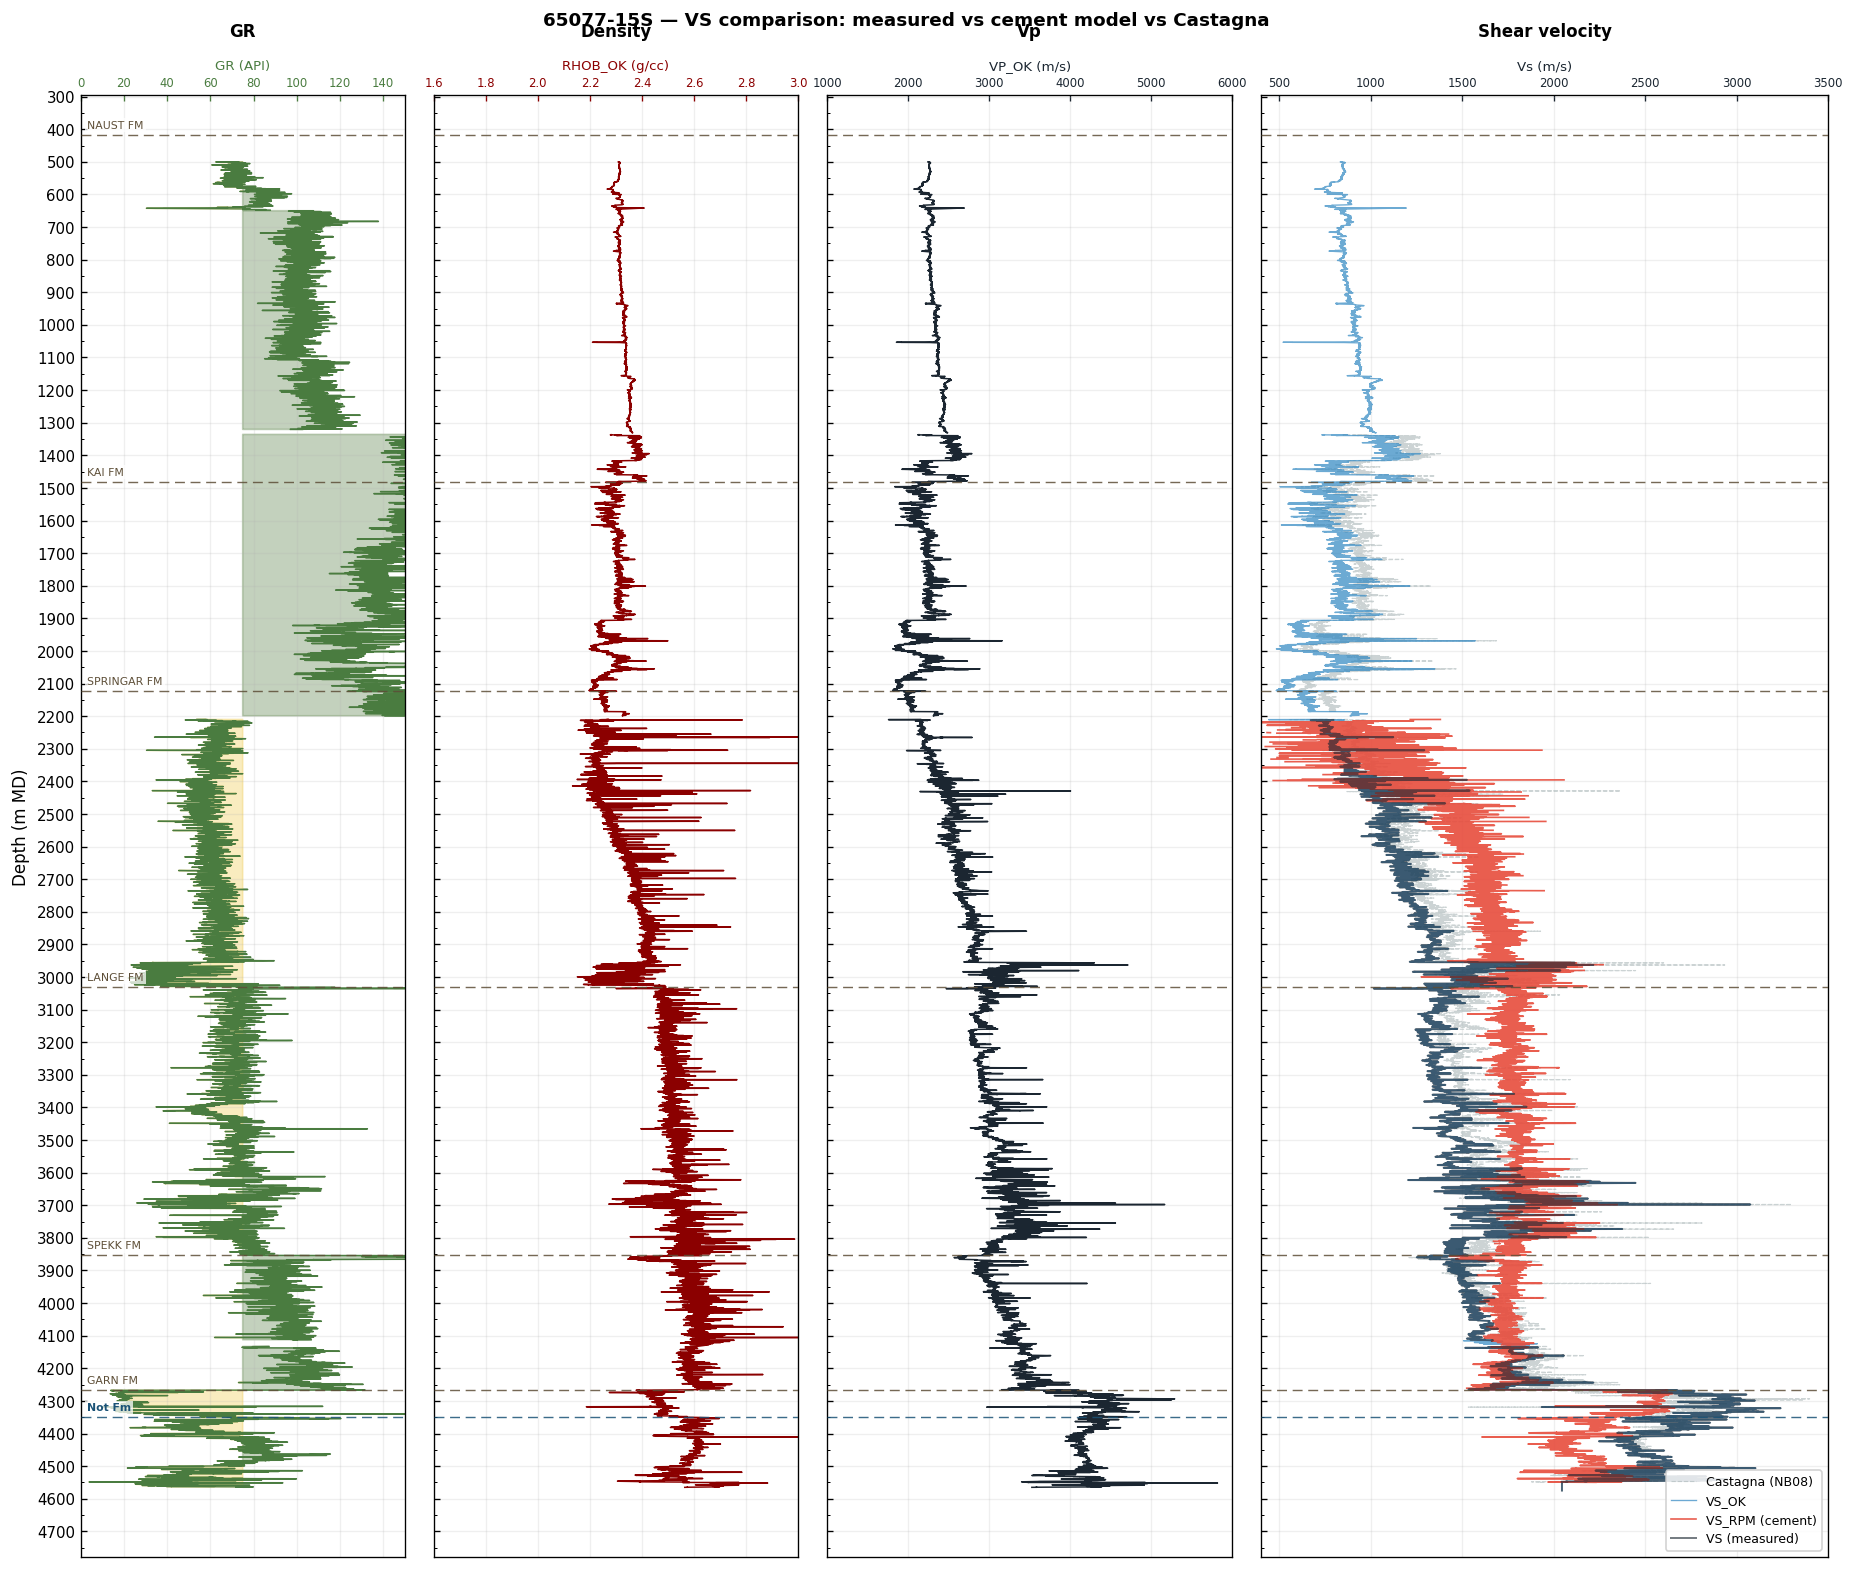

In [6]:
depth = sub.index.values
fig, axes = plt.subplots(1, 4, figsize=(16, 14), sharey=True,
                          gridspec_kw={'width_ratios': [0.8, 0.9, 1.0, 1.4]})
fig.subplots_adjust(top=0.93, bottom=0.06, left=0.07, right=0.98, wspace=0.07)

def _top_axis(ax, label, color):
    ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
    ax.set_xlabel(label, color=color, fontsize=8, labelpad=4)
    ax.tick_params(axis='x', colors=color, labelsize=7)
    ax.grid(True, alpha=0.2)

# Track 1: GR
ax = axes[0]
ax.plot(sub['GR'], depth, color='#4A7C40', lw=0.8)
ax.fill_betweenx(depth, sub['GR'], 75, where=sub['GR']>75,  color='#6B8E5A', alpha=0.4)
ax.fill_betweenx(depth, sub['GR'], 75, where=sub['GR']<=75, color='#F0D060', alpha=0.4)
ax.set_xlim(0, 150); _top_axis(ax, 'GR (API)', '#4A7C40')
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('GR', fontsize=10, fontweight='bold', pad=14)
ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

# Track 2: RHOB_OK
ax = axes[1]
ax.plot(sub['RHOB_OK'], depth, color='#8B0000', lw=0.9)
ax.set_xlim(1.6, 3.0); _top_axis(ax, 'RHOB_OK (g/cc)', '#8B0000')
ax.set_title('Density', fontsize=10, fontweight='bold', pad=14)

# Track 3: VP_OK
ax = axes[2]
ax.plot(sub['VP_OK'], depth, color='#1B2631', lw=0.9)
ax.set_xlim(1000, 6000); _top_axis(ax, 'VP_OK (m/s)', '#1B2631')
ax.set_title('Vp', fontsize=10, fontweight='bold', pad=14)

# Track 4: VS comparison
ax = axes[3]
if 'VS_CASTAGNA' in sub.columns:
    ax.plot(sub['VS_CASTAGNA'], depth, color='#AAB7B8', lw=0.7,
            ls='--', alpha=0.6, label='Castagna (NB08)')
ax.plot(sub['VS_OK'],  depth, color='#2E86C1', lw=0.8, alpha=0.7, label='VS_OK')
ax.plot(sub['VS_RPM'], depth, color='#E74C3C', lw=1.0, alpha=0.9, label='VS_RPM (cement)')
ax.plot(sub['VS'],     depth, color='#1B2631', lw=1.2, alpha=0.6, label='VS (measured)')
ax.set_xlim(400, 3500); _top_axis(ax, 'Vs (m/s)', '#1B2631')
ax.set_title('Shear velocity', fontsize=10, fontweight='bold', pad=14)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.85)

# Formation tops on all tracks
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)
for _name, _md_top in TOPS_MD.items():
    if not (depth.min() <= _md_top <= depth.max()): continue
    lc = '#1A5276' if _name == RESERVOIR_TOP else '#5D4E37'
    for ax in axes:
        ax.axhline(_md_top, color=lc, lw=0.85, ls=(0,(7,4)), alpha=0.85, zorder=4)
    axes[0].text(0.02, _md_top-(depth[-1]-depth[0])*0.003, _name,
                 transform=label_trans, fontsize=6.5, va='bottom', color=lc,
                 fontweight='bold' if _name == RESERVOIR_TOP else 'normal',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2), zorder=5)

fig.suptitle(f'{WELL_NAME} — VS comparison: measured vs cement model vs Castagna',
             fontsize=11, fontweight='bold')
plt.show()


## Step 9.6 — Vp–Vs Crossplot with Cement Trend Lines

Measured data (VP_OK, VS) coloured by formation. Cement model trend lines at
f_cement = 0.0, 0.02, 0.05, 0.10 (using mean VWCL for the whole interval).
Soft-sediments (uncemented) lower bound shown as dashed grey.


/Users/abd/Developer/qsi/qsi/moduli/bounds.py:86: RuntimeWarning: invalid value encountered in scalar divide
  fgu = mu1 * (9.0 * k1 + 8.0 * mu1) / (6.0 * (k1 + 2.0 * mu1))
/Users/abd/Developer/qsi/qsi/models/cemented_sand.py:186: RuntimeWarning: invalid value encountered in sqrt
  vs_sat_sort = np.sqrt(g_hs_sat / rho_sort_sat)


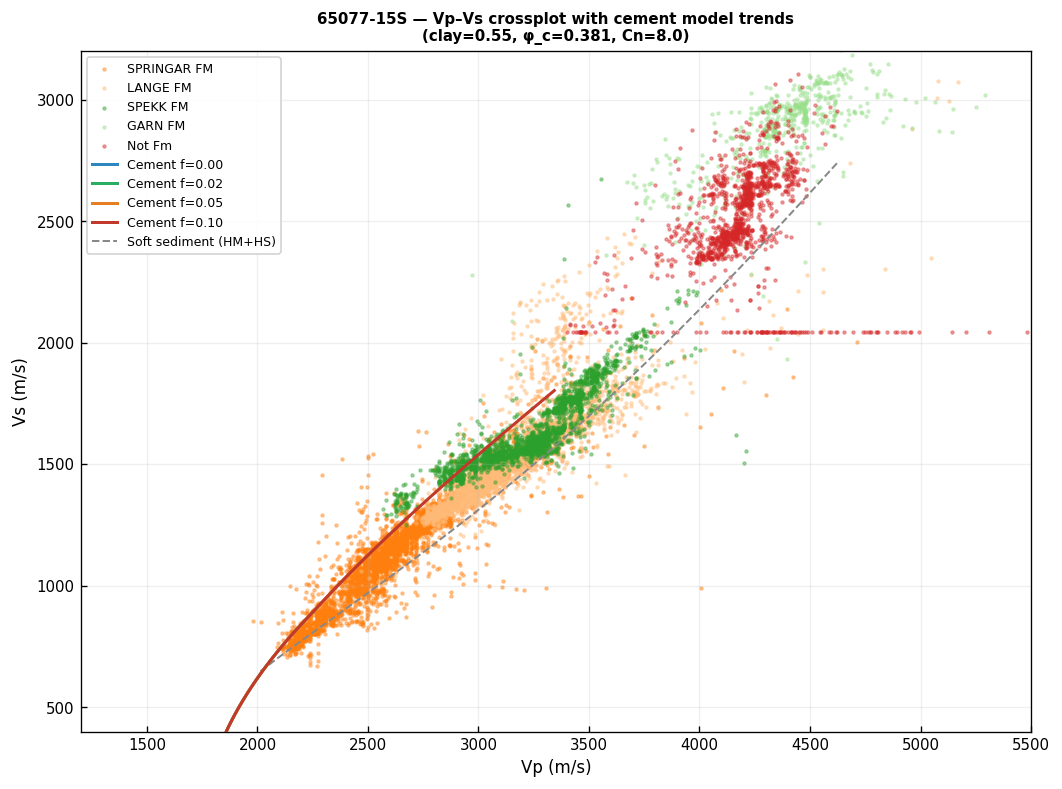

In [7]:
# ── Brine for trend lines ─────────────────────────────────────────────────────
_vp_br, _rho_br, _k_br = brine_properties(sal=SAL, P=med_P, T=med_T)
k_fl_trend  = float(_k_br)  * 1e9
rho_fl_trend = float(_rho_br) * 1e3
mean_vwcl   = float(sub['VWCL'].median())
mean_phi_c  = float(np.mean(list(phi_c_dict.values())))

# ── Cement trend lines at varying f_cement ────────────────────────────────────
F_CEMENT_VALS = [0.0, 0.02, 0.05, 0.10]
trend_colors  = ['#2E86C1', '#27AE60', '#E67E22', '#C0392B']

fig, ax = plt.subplots(figsize=(9, 7))
fig.subplots_adjust(left=0.09, right=0.97, top=0.91, bottom=0.10)

# Measured data coloured by formation
meas_mask = sub['VP_OK'].notna() & sub['VS'].notna()
for fname in [n for n,_ in top_list]:
    fd = sub[meas_mask & (sub['FORMATION'] == fname)]
    if len(fd) == 0: continue
    ax.scatter(fd['VP_OK'], fd['VS'], s=3, alpha=0.4,
               color=FORM_COLORS.get(fname,'#888'), rasterized=True, label=fname)

# Cement model trend lines
for f_cem, col in zip(F_CEMENT_VALS, trend_colors):
    try:
        out = cemented_sand(clay=mean_vwcl, phi_c=mean_phi_c, f_cement=f_cem,
                            k_fl=k_fl_trend, rho_fl=rho_fl_trend)
        phi_tr, vp_tr, vs_tr = out[0], out[1], out[2]
        ax.plot(vp_tr, vs_tr, color=col, lw=1.8, zorder=5,
                label=f'Cement f={f_cem:.2f}')
    except Exception as e:
        print(f'cemented_sand f={f_cem} failed: {e}')

# Soft-sediments (uncemented) lower bound
try:
    out_ss = soft_sediments(clay=mean_vwcl, pressure=med_P*1e6,
                             phi_c=mean_phi_c, coord=CN,
                             k_fl=k_fl_trend, rho_fl=rho_fl_trend)
    ax.plot(out_ss[4], out_ss[5], color='#888', lw=1.2, ls='--',
            zorder=4, label='Soft sediment (HM+HS)')
except Exception as e:
    print(f'soft_sediments failed: {e}')

ax.set_xlim(1200, 5500); ax.set_ylim(400, 3200)
ax.set_xlabel('Vp (m/s)', fontsize=10)
ax.set_ylabel('Vs (m/s)', fontsize=10)
ax.legend(fontsize=7.5, loc='upper left', framealpha=0.85)
ax.grid(True, alpha=0.2)
ax.set_title(f'{WELL_NAME} — Vp–Vs crossplot with cement model trends\n'
             f'(clay={mean_vwcl:.2f}, φ_c={mean_phi_c:.3f}, Cn={CN})',
             fontsize=9, fontweight='bold')
plt.show()


## Step 9.7 — Vp–φ Crossplot with Cement Trend Lines

Measured VP_OK vs PHIT. Cement model Vp–φ curves at the same f_cement values.
The `cemented_sand` function returns saturated Vp directly (Gassmann applied internally).


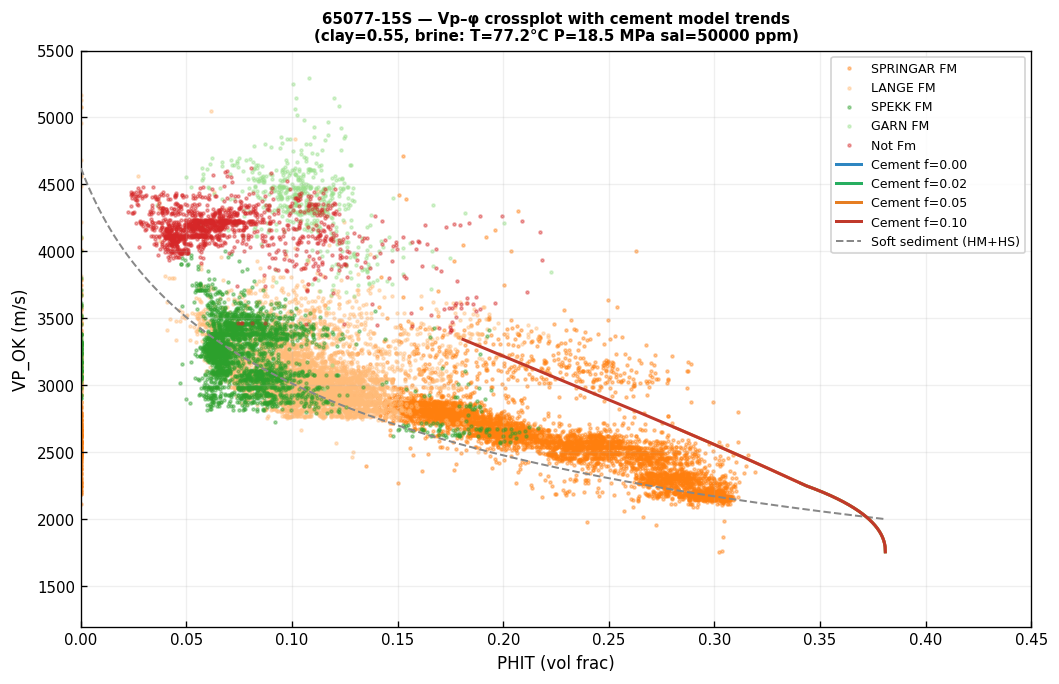

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.09, right=0.97, top=0.90, bottom=0.10)

# Measured VP_OK vs PHIT coloured by formation
meas_phi_mask = sub['VP_OK'].notna() & sub['PHIT'].notna()
for fname in [n for n,_ in top_list]:
    fd = sub[meas_phi_mask & (sub['FORMATION'] == fname)]
    if len(fd) == 0: continue
    ax.scatter(fd['PHIT'], fd['VP_OK'], s=3, alpha=0.4,
               color=FORM_COLORS.get(fname,'#888'), rasterized=True, label=fname)

# Cement Vp–φ trend lines (phi_cem is x-axis, vp_sat is y-axis)
for f_cem, col in zip(F_CEMENT_VALS, trend_colors):
    try:
        out = cemented_sand(clay=mean_vwcl, phi_c=mean_phi_c, f_cement=f_cem,
                            k_fl=k_fl_trend, rho_fl=rho_fl_trend)
        phi_tr, vp_tr = out[0], out[1]
        ax.plot(phi_tr, vp_tr, color=col, lw=1.8, zorder=5,
                label=f'Cement f={f_cem:.2f}')
    except Exception as e:
        print(f'cemented_sand f={f_cem} failed: {e}')

# Soft-sediments lower bound
try:
    out_ss = soft_sediments(clay=mean_vwcl, pressure=med_P*1e6,
                             phi_c=mean_phi_c, coord=CN,
                             k_fl=k_fl_trend, rho_fl=rho_fl_trend)
    ax.plot(out_ss[0], out_ss[4], color='#888', lw=1.2, ls='--',
            zorder=4, label='Soft sediment (HM+HS)')
except Exception as e:
    print(f'soft_sediments failed: {e}')

ax.set_xlim(0, 0.45); ax.set_ylim(1200, 5500)
ax.set_xlabel('PHIT (vol frac)', fontsize=10)
ax.set_ylabel('VP_OK (m/s)', fontsize=10)
ax.legend(fontsize=7.5, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.2)
ax.set_title(f'{WELL_NAME} — Vp–φ crossplot with cement model trends\n'
             f'(clay={mean_vwcl:.2f}, brine: T={med_T:.1f}°C P={med_P:.1f} MPa sal={SAL} ppm)',
             fontsize=9, fontweight='bold')
plt.show()


## Step 9.8 — Save Output


In [9]:
out_cols = ['VS_RPM', 'PHI_C_CEMENT', 'K_MIN', 'G_MIN']
out_full = sub[out_cols].reindex(df.index)
out_full.to_parquet(OUT_FILE)

print(f'Saved : {OUT_FILE}')
print(f'Columns: {out_cols}')
print(f'Rows   : {len(out_full):,}')
print()
print('VS_RPM statistics:')
print(sub['VS_RPM'].describe().round(1).to_string())

# ── Phase summary markdown table ──────────────────────────────────────────────
print()
print('Phase 9 Summary')
print('─' * 60)
print(f'  Mineral mixing  : VRH (quartz + clay via VWCL)')
print(f'  Cement model    : Dvorkin-Nur contact cement (scheme {SCHEME})')
print(f'  Coord number Cn : {CN} (fixed)')
print(f'  Calibration     : phi_c per formation (min 30 pts)')
for fname, phi_c_v in phi_c_dict.items():
    print(f'    {fname:<20}: phi_c = {phi_c_v:.3f}')
print(f'  VS_RPM valid    : {sub["VS_RPM"].notna().sum():,} samples')
print(f'  Output          : {OUT_FILE}')


Saved : ../wells/65077-15S_rockphysics.parquet
Columns: ['VS_RPM', 'PHI_C_CEMENT', 'K_MIN', 'G_MIN']
Rows   : 30,119

VS_RPM statistics:
count    14650.0
mean      1751.4
std        308.8
min        175.0
25%       1653.8
50%       1754.5
75%       1843.9
max       2662.0

Phase 9 Summary
────────────────────────────────────────────────────────────
  Mineral mixing  : VRH (quartz + clay via VWCL)
  Cement model    : Dvorkin-Nur contact cement (scheme 2)
  Coord number Cn : 8.0 (fixed)
  Calibration     : phi_c per formation (min 30 pts)
    NAUST FM            : phi_c = 0.400
    KAI FM              : phi_c = 0.400
    SPRINGAR FM         : phi_c = 0.300
    LANGE FM            : phi_c = 0.300
    SPEKK FM            : phi_c = 0.300
    GARN FM             : phi_c = 0.488
    Not Fm              : phi_c = 0.478
  VS_RPM valid    : 14,650 samples
  Output          : ../wells/65077-15S_rockphysics.parquet


---
## Phase 9 Summary

| Item | Value |
|------|-------|
| Mineral mixing | VRH Hill average, quartz + clay |
| Cement model | Dvorkin-Nur contact cement (qsi), scheme 2 |
| Calibration parameter | φ_c per formation (scipy minimize_scalar, bounds 0.30–0.50) |
| Coordination number | 8.0 (fixed; explore later) |
| Fluid (for trend lines) | Batzle-Wang brine (qsi.fluids) at median T/P |
| VS_RPM valid | See Step 9.4 output |
| Output | `wells/{WELL_NAME}_rockphysics.parquet` |

**Next**: Notebook `10_` — fluid substitution (Gassmann) using VS_RPM + calibrated φ_c.
